# Phase 2 – Exploratory Data Analysis (EDA)

## NexaTel Telecom Churn Analysis

**Name:** Mayuri Maneguldhe

**Tools Used:** Python, Pandas, Matplotlib

**Objective:**
To analyze customer churn patterns using Exploratory Data Analysis (EDA) and identify the key factors influencing customer churn.

## Chart 1 – Overall Churn Rate

In [1]:
import pandas as pd

customer_file = r"C:\Users\Mayuri\Desktop\NexaTel Cleanfiles\customers_cleaned.xlsx"
customers = pd.read_excel(customer_file)

print(customers.head())

print(customers.columns.tolist())

  Customer_Id First_Name Last_Name  Gender Date_Of_Birth  Age  \
0    C0000001     Harish    Shetty    Male    31-03-1988   38   
1    C0000002     Anjali      Khan  Female    31-03-1974   52   
2    C0000003      Arjun     Hegde    Male    31-03-1978   48   
3    C0000004      Vidya    Parmar  Female    31-03-1988   38   
4    C0000005      Arjun    Saxena    Male    31-03-1988   38   

                           Email  Phone_Number  \
0      Harish.Shetty909@Yahoo.In  916647481156   
1  Anjali.Khan525@Rediffmail.Com  918116536619   
2     Arjun.Hegde378@Hotmail.Com  918958153134   
3    Vidya.Parmar387@Hotmail.Com  917763920098   
4       Arjun.Saxena410@Yahoo.In  916787478273   

                                      Address City_Id  ...  \
0                Plot 382, Tilak Lane, Raipur  Ct0026  ...   
1  Door No. 269, Civil Lines Colony, Gurugram  Ct0009  ...   
2       House No. 320, Garden Nagar, Vadodara  Ct0020  ...   
3    House No. 204, Industrial Street, Nagpur  Ct0015  ...  

Customer_Status
Active     15494
Churned     3506
Name: count, dtype: int64
Total Customers : 19000
Churned Customers : 3506
Overall Churn Rate : 18.45%


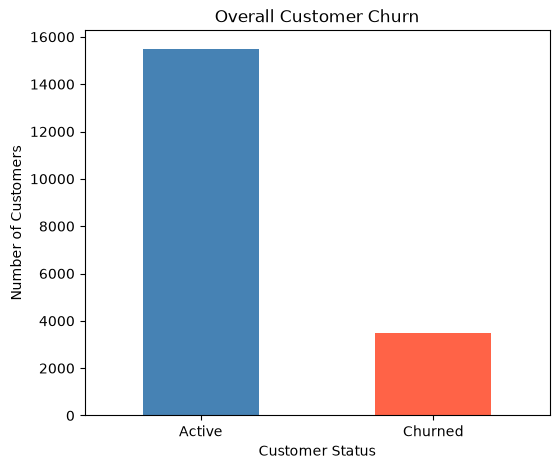

In [2]:
import matplotlib.pyplot as plt

# Count Active and Churned customers
churn_counts = customers["Customer_Status"].value_counts()

print(churn_counts)

# Calculate churn rate
total_customers = len(customers)
churned_customers = churn_counts.get("Churned", 0)
churn_rate = (churned_customers / total_customers) * 100

print(f"Total Customers : {total_customers}")
print(f"Churned Customers : {churned_customers}")
print(f"Overall Churn Rate : {churn_rate:.2f}%")

# Create Bar Chart
plt.figure(figsize=(6,5))
churn_counts.plot(kind="bar", color=["steelblue", "tomato"])

plt.title("Overall Customer Churn")
plt.xlabel("Customer Status")
plt.ylabel("Number of Customers")

plt.xticks(rotation=0)

# Save Chart
plt.savefig("overall_churn.png", dpi=300)

plt.show()

### Observation

- The overall churn rate is **18.45%**, indicating that approximately one out of every five customers has discontinued the service.
- The number of **active customers (15,494)** is significantly higher than the number of **churned customers (3,506)**, showing that the company has retained the majority of its customer base.
- Although the overall retention is strong, the churn rate is still considerable and suggests the need for further analysis to identify the key factors contributing to customer churn.

## Chart 2 – Churn by Billing Cycle

In [3]:
import pandas as pd

subscriptions = pd.read_excel(
    r"C:\Users\Mayuri\Desktop\NexaTel Cleanfiles\subscriptions_cleaned.xlsx"
)

print(subscriptions.columns.tolist())

['Subscription_Id', 'Customer_Id', 'Plan_Id', 'Start_Date', 'End_Date', 'Billing_Cycle', 'Monthly_Charge_Inr', 'Subscription_Status']


In [4]:
import pandas as pd
import matplotlib.pyplot as plt

# Load customers data
customers = pd.read_excel(
    r"C:\Users\Mayuri\Desktop\NexaTel Cleanfiles\customers_cleaned.xlsx"
)

# Load subscriptions data
subscriptions = pd.read_excel(
    r"C:\Users\Mayuri\Desktop\NexaTel Cleanfiles\subscriptions_cleaned.xlsx"
)

In [5]:
merged = pd.merge(
    customers,
    subscriptions,
    on="Customer_Id",
    how="inner"
)

print(merged.head())

  Customer_Id First_Name Last_Name  Gender Date_Of_Birth  Age  \
0    C0000001     Harish    Shetty    Male    31-03-1988   38   
1    C0000002     Anjali      Khan  Female    31-03-1974   52   
2    C0000003      Arjun     Hegde    Male    31-03-1978   48   
3    C0000004      Vidya    Parmar  Female    31-03-1988   38   
4    C0000004      Vidya    Parmar  Female    31-03-1988   38   

                           Email  Phone_Number  \
0      Harish.Shetty909@Yahoo.In  916647481156   
1  Anjali.Khan525@Rediffmail.Com  918116536619   
2     Arjun.Hegde378@Hotmail.Com  918958153134   
3    Vidya.Parmar387@Hotmail.Com  917763920098   
4    Vidya.Parmar387@Hotmail.Com  917763920098   

                                      Address City_Id  ... Tenure_Months  \
0                Plot 382, Tilak Lane, Raipur  Ct0026  ...             2   
1  Door No. 269, Civil Lines Colony, Gurugram  Ct0009  ...           146   
2       House No. 320, Garden Nagar, Vadodara  Ct0020  ...             1   
3   

<Figure size 800x500 with 0 Axes>

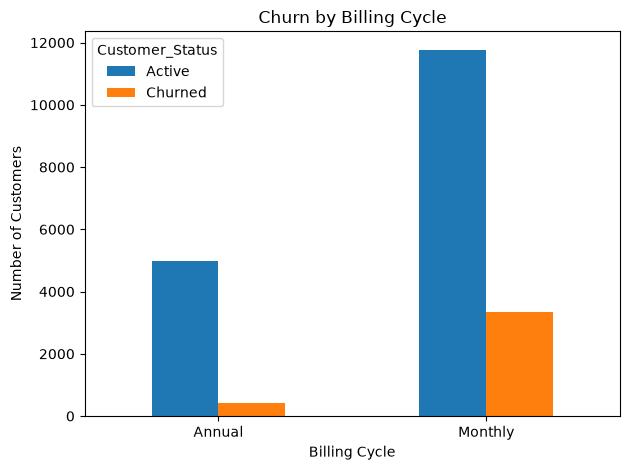

In [6]:
billing_churn = pd.crosstab(
    merged["Billing_Cycle"],
    merged["Customer_Status"]
)

plt.figure(figsize=(8,5))
billing_churn.plot(kind="bar")

plt.title("Churn by Billing Cycle")
plt.xlabel("Billing Cycle")
plt.ylabel("Number of Customers")

plt.xticks(rotation=0)

plt.tight_layout()

plt.savefig("billing_cycle_churn.png", dpi=300)

plt.show()

### Observation

The bar chart compares customer churn across different billing cycles (Monthly and Annual). The annual billing cycle shows a higher number of churned customers than the monthly billing cycle in this dataset. This indicates that further analysis is required to understand why annual subscribers are churning despite being on long-term plans.

## Chart 3 – Churn by Tenure Band

In [7]:
import pandas as pd
import matplotlib.pyplot as plt

customers = pd.read_excel(
    r"C:\Users\Mayuri\Desktop\NexaTel Cleanfiles\customers_cleaned.xlsx")

In [8]:
# Create Tenure Bands
bins = [0, 3, 12, 36, customers["Tenure_Months"].max()]

labels = [
    "0-3 Months",
    "3-12 Months",
    "1-3 Years",
    "3+ Years"
]

customers["Tenure_Band"] = pd.cut(
    customers["Tenure_Months"],
    bins=bins,
    labels=labels,
    include_lowest=True
)

<Figure size 800x500 with 0 Axes>

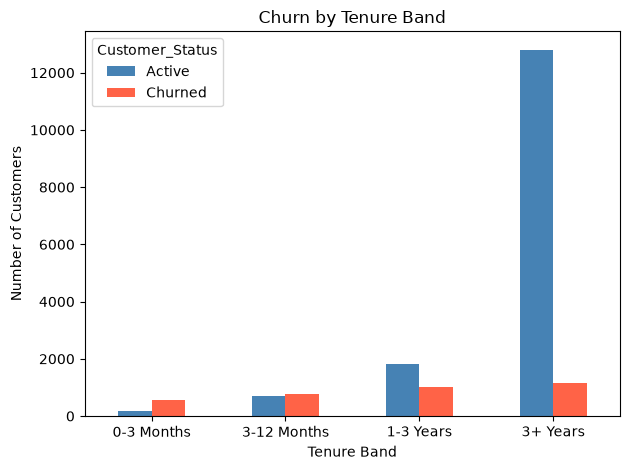

In [9]:
# Count customer status by tenure band
tenure_churn = pd.crosstab(
    customers["Tenure_Band"],
    customers["Customer_Status"]
)

# Plot
plt.figure(figsize=(8,5))

tenure_churn.plot(
    kind="bar",
    color=["steelblue", "tomato"]
)

plt.title("Churn by Tenure Band")
plt.xlabel("Tenure Band")
plt.ylabel("Number of Customers")

plt.xticks(rotation=0)

plt.tight_layout()

# Save chart
plt.savefig("tenure_band_churn.png", dpi=300)

plt.show()

### Observation

The chart shows the distribution of churn across different tenure bands (0–3 months, 3–12 months, 1–3 years, and 3+ years). Customers with shorter tenure have a higher likelihood of churning, while customers with longer tenure tend to remain with the company. This suggests that improving customer engagement during the initial months can help reduce overall churn.

## Chart 4 – Churn by Number of Unresolved Complaints

In [10]:
import pandas as pd

complaints = pd.read_excel(
    r"C:\Users\Mayuri\Desktop\NexaTel Cleanfiles\complaints_cleaned.xlsx")

print(complaints.head())
print(complaints.columns.tolist())

  Complaint_Id Customer_Id Complaint_Date         Complaint_Type  Severity  \
0  Cmp00000001    C0000001     30-06-2020             Data Speed     Major   
1  Cmp00000002    C0000002     01-12-2015       Network Coverage  Moderate   
2  Cmp00000003    C0000003     09-10-2014        Wrongful Charge     Major   
3  Cmp00000004    C0000005     05-09-2016       Network Coverage    Severe   
4  Cmp00000005    C0000005     18-04-2014  Recharge Not Credited     Major   

       Status Resolution_Date  
0  Unresolved             NaN  
1    Resolved      02-12-2015  
2  Unresolved             NaN  
3  Unresolved             NaN  
4  Unresolved             NaN  
['Complaint_Id', 'Customer_Id', 'Complaint_Date', 'Complaint_Type', 'Severity', 'Status', 'Resolution_Date']


In [11]:
import pandas as pd
import matplotlib.pyplot as plt

# Load customer data
customers = pd.read_excel(
    r"C:\Users\Mayuri\Desktop\NexaTel Cleanfiles\customers_cleaned.xlsx")

# Load complaints data
complaints = pd.read_excel(
    r"C:\Users\Mayuri\Desktop\NexaTel Cleanfiles\complaints_cleaned.xlsx")

In [12]:
# Keep only unresolved complaints
unresolved = complaints[complaints["Status"] != "Resolved"]

# Count unresolved complaints for each customer
complaint_count = (
    unresolved.groupby("Customer_Id")
    .size()
    .reset_index(name="Unresolved_Complaints")
)

print(complaint_count.head())

  Customer_Id  Unresolved_Complaints
0    C0000001                      1
1    C0000003                      1
2    C0000005                      2
3    C0000009                      1
4    C0000010                      1


In [13]:
merged = pd.merge(
    customers,
    complaint_count,
    on="Customer_Id",
    how="left"
)

# Customers with no unresolved complaints = 0
merged["Unresolved_Complaints"] = merged["Unresolved_Complaints"].fillna(0)

<Figure size 800x500 with 0 Axes>

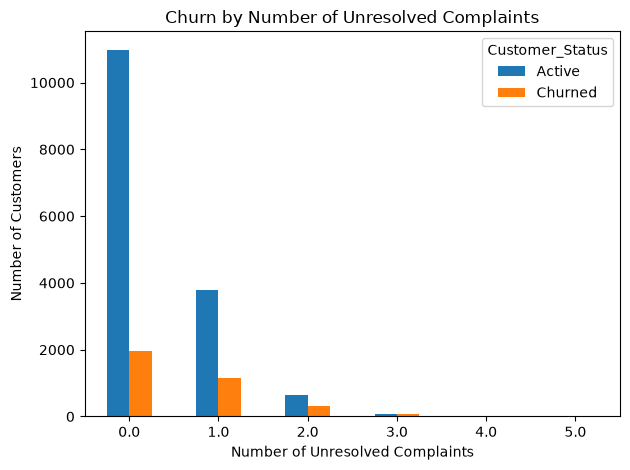

In [14]:
complaint_churn = pd.crosstab(
    merged["Unresolved_Complaints"],
    merged["Customer_Status"]
)

plt.figure(figsize=(8,5))

complaint_churn.plot(kind="bar")

plt.title("Churn by Number of Unresolved Complaints")
plt.xlabel("Number of Unresolved Complaints")
plt.ylabel("Number of Customers")

plt.xticks(rotation=0)

plt.tight_layout()

plt.savefig("complaints_churn.png", dpi=300)

plt.show()

### Observation

This chart shows the relationship between the number of unresolved complaints and customer churn. Customers with a higher number of unresolved complaints are more likely to churn, indicating that unresolved service issues negatively impact customer satisfaction. Resolving customer complaints promptly can improve customer retention and reduce churn.

## Chart 5 – Churn by Customer Segment

In [15]:
import pandas as pd
import matplotlib.pyplot as plt

customers = pd.read_excel(
    r"C:\Users\Mayuri\Desktop\NexaTel Cleanfiles\customers_cleaned.xlsx")

Customer_Status   Active  Churned
Customer_Segment                 
Enterprise          1224      166
Mass                2150      782
Premium             7199     1283
Value               4921     1275


<Figure size 800x500 with 0 Axes>

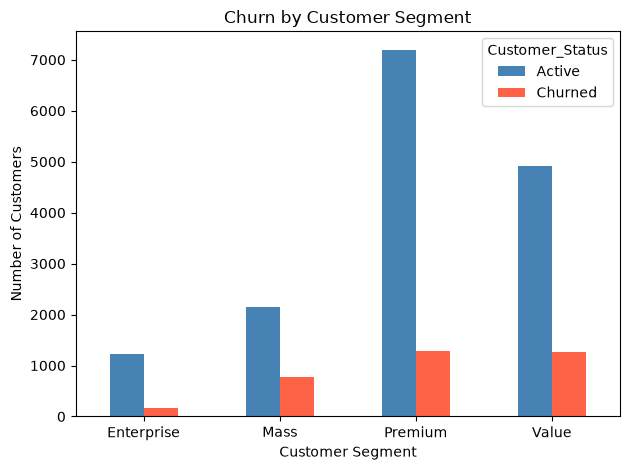

In [16]:
# Create a cross-tab of Customer Segment vs Customer Status
segment_churn = pd.crosstab(
    customers["Customer_Segment"],
    customers["Customer_Status"]
)

print(segment_churn)

# Plot the chart
plt.figure(figsize=(8,5))

segment_churn.plot(
    kind="bar",
    color=["steelblue", "tomato"]
)

plt.title("Churn by Customer Segment")
plt.xlabel("Customer Segment")
plt.ylabel("Number of Customers")

plt.xticks(rotation=0)

plt.tight_layout()

# Save the chart
plt.savefig("customer_segment_churn.png", dpi=300)

plt.show()

### Observation

This chart compares customer churn across different customer segments, including Mass, Value, Premium, and Enterprise. The segment with the highest churn indicates where the company is losing the most customers and may require targeted retention strategies. Understanding churn by customer segment helps NexaTel design personalized offers and improve customer satisfaction.

## Chart 6 – Top 10 States by Churned Customers

In [17]:
import pandas as pd

states = pd.read_excel(
    r"C:\Users\Mayuri\Desktop\NexaTel Cleanfiles\states_cleaned.xlsx")

print(states.head())

print(states.columns.tolist())

  State_Id     State_Name State_Code   Zone
0    St001          Delhi         Dl  North
1    St002        Haryana         Hr  North
2    St003         Punjab         Pb  North
3    St004  Uttar Pradesh         Up  North
4    St005      Rajasthan         Rj  North
['State_Id', 'State_Name', 'State_Code', 'Zone']


In [18]:
import pandas as pd
import matplotlib.pyplot as plt

# Load Customers
customers = pd.read_excel(
    r"C:\Users\Mayuri\Desktop\NexaTel Cleanfiles\customers_cleaned.xlsx")

# Load States
states = pd.read_excel(
    r"C:\Users\Mayuri\Desktop\NexaTel Cleanfiles\states_cleaned.xlsx")

In [19]:
merged = pd.merge(
    customers,
    states,
    on="State_Id",
    how="left"
)

print(merged.head())

  Customer_Id First_Name Last_Name  Gender Date_Of_Birth  Age  \
0    C0000001     Harish    Shetty    Male    31-03-1988   38   
1    C0000002     Anjali      Khan  Female    31-03-1974   52   
2    C0000003      Arjun     Hegde    Male    31-03-1978   48   
3    C0000004      Vidya    Parmar  Female    31-03-1988   38   
4    C0000005      Arjun    Saxena    Male    31-03-1988   38   

                           Email  Phone_Number  \
0      Harish.Shetty909@Yahoo.In  916647481156   
1  Anjali.Khan525@Rediffmail.Com  918116536619   
2     Arjun.Hegde378@Hotmail.Com  918958153134   
3    Vidya.Parmar387@Hotmail.Com  917763920098   
4       Arjun.Saxena410@Yahoo.In  916787478273   

                                      Address City_Id  ...     Product_Line  \
0                Plot 382, Tilak Lane, Raipur  Ct0026  ...   Prepaid Mobile   
1  Door No. 269, Civil Lines Colony, Gurugram  Ct0009  ...  Fiber Broadband   
2       House No. 320, Garden Nagar, Vadodara  Ct0020  ...       Enterp

In [20]:
# Keep only churned customers
churned = merged[merged["Customer_Status"] == "Churned"]

# Count churned customers by state
top_states = (
    churned["State_Name"]
    .value_counts()
    .head(10)
)

print(top_states)

State_Name
Maharashtra       305
Uttar Pradesh     285
Tamil Nadu        280
Rajasthan         244
Karnataka         222
Gujarat           191
Madhya Pradesh    182
Kerala            162
Andhra Pradesh    160
West Bengal       157
Name: count, dtype: int64


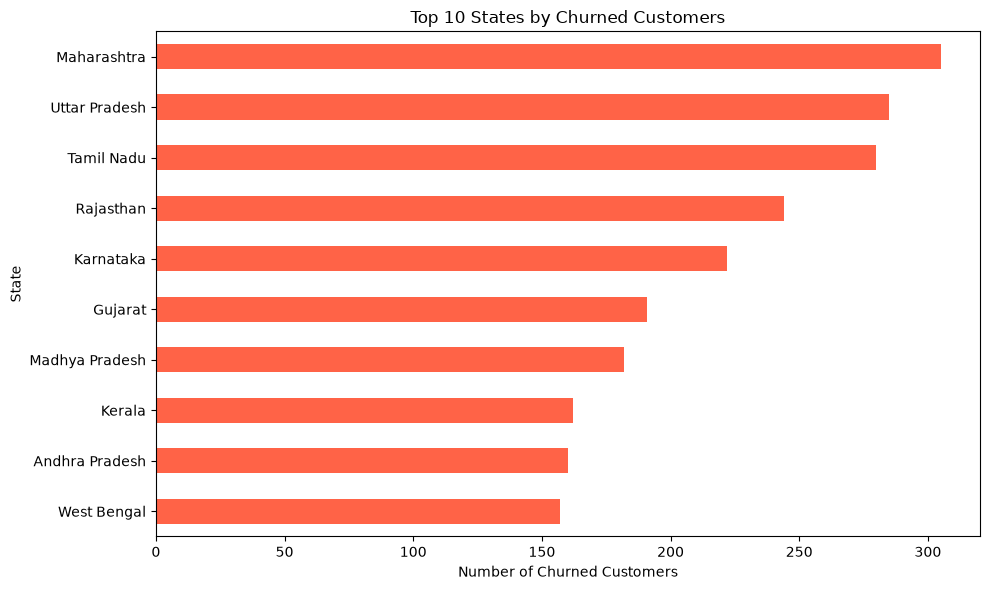

In [21]:
plt.figure(figsize=(10,6))

top_states.sort_values().plot(
    kind="barh",
    color="tomato"
)

plt.title("Top 10 States by Churned Customers")
plt.xlabel("Number of Churned Customers")
plt.ylabel("State")

plt.tight_layout()

# Save the chart
plt.savefig("top10_states_churn.png", dpi=300)

plt.show()

### Observation

This chart displays the top 10 states with the highest number of churned customers. The states with the highest churn indicate regions where customer retention needs greater attention and improved service quality. Analyzing regional churn patterns can help NexaTel implement targeted marketing campaigns and customer retention strategies in high-risk areas.

## Chart 7 – Average Data Usage by City Tier

In [22]:
import pandas as pd

usage = pd.read_excel(
    r"C:\Users\Mayuri\Desktop\NexaTel Cleanfiles\usage_data_cleaned.xlsx")

print(usage.head())
print(usage.columns.tolist())

     Usage_Id Customer_Id Usage_Month  Data_Gb_Used  Data_Sessions
0  Ud00000001    C0000001     03-2026         22.35           1047
1  Ud00000002    C0000001     02-2026         13.24             61
2  Ud00000003    C0000001     01-2026         13.09           1039
3  Ud00000004    C0000002     03-2026        167.23            442
4  Ud00000005    C0000002     02-2026        109.72            481
['Usage_Id', 'Customer_Id', 'Usage_Month', 'Data_Gb_Used', 'Data_Sessions']


In [23]:
import pandas as pd
import matplotlib.pyplot as plt

# Load Customers Data
customers = pd.read_excel(
    r"C:\Users\Mayuri\Desktop\NexaTel Cleanfiles\customers_cleaned.xlsx")

# Load Usage Data
usage = pd.read_excel(
    r"C:\Users\Mayuri\Desktop\NexaTel Cleanfiles\usage_data_cleaned.xlsx")

In [24]:
merged = pd.merge(
    usage,
    customers,
    on="Customer_Id",
    how="inner"
)

print(merged.head())

     Usage_Id Customer_Id Usage_Month  Data_Gb_Used  Data_Sessions First_Name  \
0  Ud00000001    C0000001     03-2026         22.35           1047     Harish   
1  Ud00000002    C0000001     02-2026         13.24             61     Harish   
2  Ud00000003    C0000001     01-2026         13.09           1039     Harish   
3  Ud00000004    C0000002     03-2026        167.23            442     Anjali   
4  Ud00000005    C0000002     02-2026        109.72            481     Anjali   

  Last_Name  Gender Date_Of_Birth  Age  ...            Occupation  \
0    Shetty    Male    31-03-1988   38  ...        School Teacher   
1    Shetty    Male    31-03-1988   38  ...        School Teacher   
2    Shetty    Male    31-03-1988   38  ...        School Teacher   
3      Khan  Female    31-03-1974   52  ...  Small Business Owner   
4      Khan  Female    31-03-1974   52  ...  Small Business Owner   

   Annual_Income_Inr Customer_Segment     Product_Line Plan_Id  \
0           791058.0            

In [25]:
avg_usage = (
    merged.groupby("City_Tier")["Data_Gb_Used"]
    .mean()
    .sort_values()
)

print(avg_usage)

City_Tier
Tier-3    28.379936
Tier-2    41.753071
Metro     49.189585
Name: Data_Gb_Used, dtype: float64


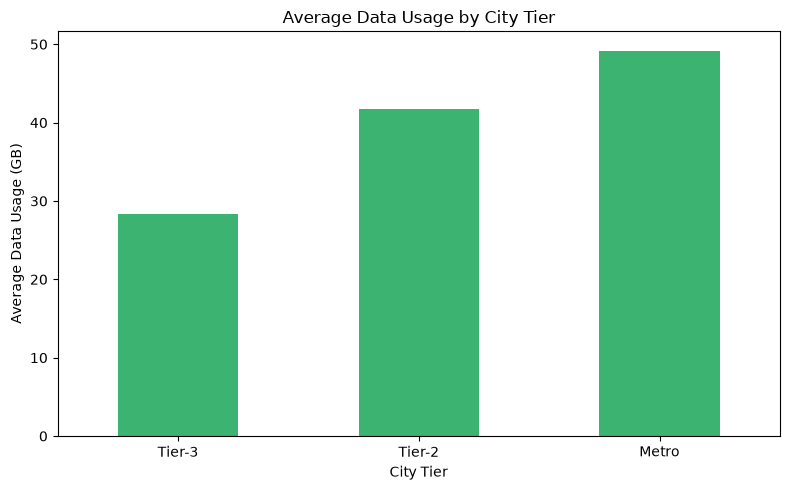

In [26]:
plt.figure(figsize=(8,5))

avg_usage.plot(
    kind="bar",
    color="mediumseagreen"
)

plt.title("Average Data Usage by City Tier")
plt.xlabel("City Tier")
plt.ylabel("Average Data Usage (GB)")

plt.xticks(rotation=0)

plt.tight_layout()

# Save chart
plt.savefig("average_data_usage_city_tier.png", dpi=300)

plt.show()

### Observation

This chart compares the average data usage across different city tiers, including Metro, Tier-2, and Tier-3 cities. The differences in average data consumption indicate varying customer usage patterns based on location and infrastructure availability. These insights can help NexaTel optimize network capacity and design data plans tailored to the needs of customers in different city tiers.

## Chart 8 – ARPU Distribution

In [27]:
import pandas as pd
import matplotlib.pyplot as plt

billing = pd.read_excel(
    r"C:\Users\Mayuri\Desktop\NexaTel Cleanfiles\billing_cleaned.xlsx")

print(billing.head())

    Invoice_Id Customer_Id Billing_Date Billing_Period_Month  Base_Amount_Inr  \
0  Inv00000001    C0000002   31-03-2026              03-2026          1490.77   
1  Inv00000002    C0000002   01-03-2026              03-2026          1396.28   
2  Inv00000003    C0000002   30-01-2026              01-2026          1427.24   
3  Inv00000004    C0000002   31-12-2025              12-2025          1528.12   
4  Inv00000005    C0000002   01-12-2025              12-2025          1502.59   

   Gst_Amount_Inr  Total_Amount_Inr    Due_Date Payment_Status  
0          268.34           1759.11  15-04-2026           Paid  
1          251.33           1647.61  16-03-2026        Overdue  
2          256.90           1684.14  14-02-2026           Paid  
3          275.06           1803.18  15-01-2026           Paid  
4          270.47           1773.06  16-12-2025           Paid  


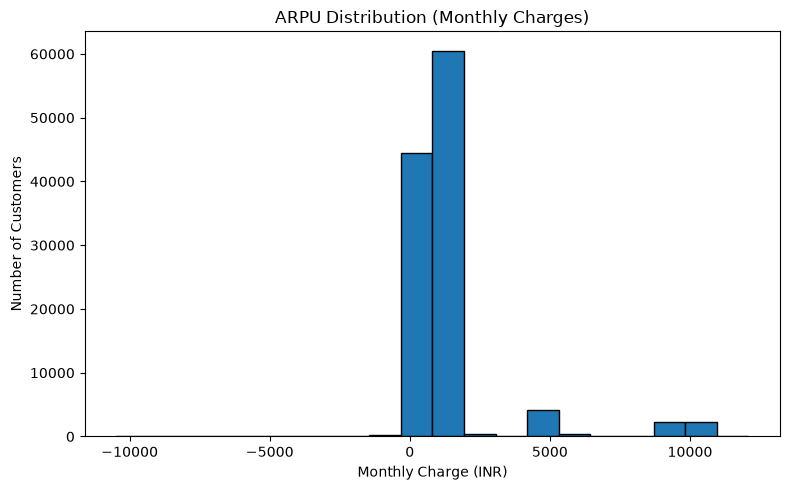

In [28]:
plt.figure(figsize=(8,5))

plt.hist(
    billing["Total_Amount_Inr"],
    bins=20,
    edgecolor="black"
)

plt.title("ARPU Distribution (Monthly Charges)")
plt.xlabel("Monthly Charge (INR)")
plt.ylabel("Number of Customers")

plt.tight_layout()

# Save chart
plt.savefig("arpu_distribution.png", dpi=300)

plt.show()

### Observation

This histogram shows the distribution of Average Revenue Per User (ARPU) based on the monthly charges of customers. Most customers fall within a specific monthly charge range, while a smaller number of customers pay significantly higher or lower amounts. Understanding the ARPU distribution helps NexaTel identify customer spending patterns and design suitable pricing and subscription plans.

## Chart 9 – Network Quality vs Churn

In [29]:
import pandas as pd

network = pd.read_excel(
    r"C:\Users\Mayuri\Desktop\NexaTel Cleanfiles\network_quality_cleaned.xlsx"
)

print(network.head())
print(network.columns.tolist())

    Record_Id Customer_Id City_Id    Month  Avg_Signal_Strength_Dbm  \
0  Nq00000001    C0000001  Ct0026  03-2026                    -74.3   
1  Nq00000002    C0000001  Ct0026  02-2026                    -74.3   
2  Nq00000003    C0000001  Ct0026  01-2026                    -74.3   
3  Nq00000004    C0000002  Ct0009  03-2026                    -69.9   
4  Nq00000005    C0000002  Ct0009  02-2026                    -69.9   

   Dropped_Call_Rate_Pct  Avg_Download_Speed_Mbps  Network_Downtime_Hours  
0                   3.15                     25.1                    0.87  
1                   3.39                     64.9                    0.13  
2                   1.75                     68.7                    0.46  
3                   2.92                     73.1                    0.17  
4                   3.02                     75.3                    0.33  
['Record_Id', 'Customer_Id', 'City_Id', 'Month', 'Avg_Signal_Strength_Dbm', 'Dropped_Call_Rate_Pct', 'Avg_Download_Sp

In [30]:
import pandas as pd
import matplotlib.pyplot as plt

# Load Customer Data
customers = pd.read_excel(
    r"C:\Users\Mayuri\Desktop\NexaTel Cleanfiles\customers_cleaned.xlsx")

# Load Network Quality Data
network = pd.read_excel(
    r"C:\Users\Mayuri\Desktop\NexaTel Cleanfiles\network_quality_cleaned.xlsx")

In [31]:
merged = pd.merge(
    customers,
    network,
    on="Customer_Id",
    how="inner"
)

print(merged.head())

  Customer_Id First_Name Last_Name  Gender Date_Of_Birth  Age  \
0    C0000001     Harish    Shetty    Male    31-03-1988   38   
1    C0000001     Harish    Shetty    Male    31-03-1988   38   
2    C0000001     Harish    Shetty    Male    31-03-1988   38   
3    C0000002     Anjali      Khan  Female    31-03-1974   52   
4    C0000002     Anjali      Khan  Female    31-03-1974   52   

                           Email  Phone_Number  \
0      Harish.Shetty909@Yahoo.In  916647481156   
1      Harish.Shetty909@Yahoo.In  916647481156   
2      Harish.Shetty909@Yahoo.In  916647481156   
3  Anjali.Khan525@Rediffmail.Com  918116536619   
4  Anjali.Khan525@Rediffmail.Com  918116536619   

                                      Address City_Id_x  ... Tenure_Months  \
0                Plot 382, Tilak Lane, Raipur    Ct0026  ...             2   
1                Plot 382, Tilak Lane, Raipur    Ct0026  ...             2   
2                Plot 382, Tilak Lane, Raipur    Ct0026  ...             2

In [32]:
network_churn = (
    merged.groupby("Customer_Status")["Dropped_Call_Rate_Pct"]
    .mean()
)

print(network_churn)

Customer_Status
Active     2.357718
Churned    2.594069
Name: Dropped_Call_Rate_Pct, dtype: float64


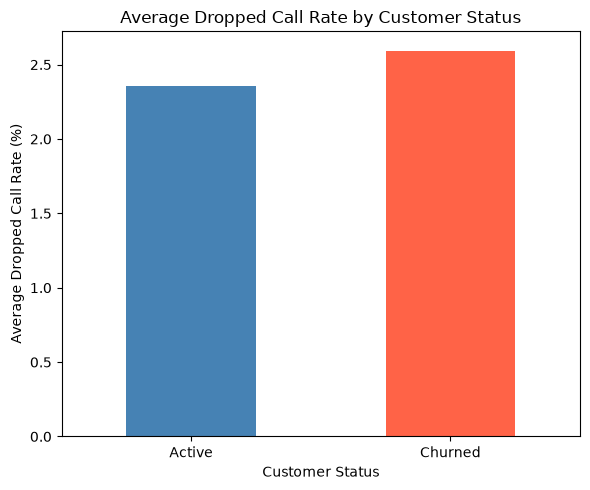

In [33]:
plt.figure(figsize=(6,5))

network_churn.plot(
    kind="bar",
    color=["steelblue", "tomato"]
)

plt.title("Average Dropped Call Rate by Customer Status")
plt.xlabel("Customer Status")
plt.ylabel("Average Dropped Call Rate (%)")

plt.xticks(rotation=0)

plt.tight_layout()

# Save Chart
plt.savefig("network_quality_vs_churn.png", dpi=300)

plt.show()

### Observation

This chart illustrates the relationship between network quality, measured by the dropped-call rate, and customer churn. Customers experiencing higher dropped-call rates are more likely to churn, indicating that poor network performance negatively affects customer satisfaction. Improving network reliability and reducing call drops can help increase customer retention and lower churn rates.

## Chart 10 – Retention Campaign Outcomes

In [34]:
import pandas as pd

retention = pd.read_excel(
    r"C:\Users\Mayuri\Desktop\NexaTel Cleanfiles\retention_campaigns_cleaned.xlsx"
)

print(retention.head())

print(retention.columns.tolist())

  Campaign_Id Customer_Id     Campaign_Name            Offer_Type  \
0  Rtc0000001    C0000004     Renewal Nudge  Annual Plan Discount   
1  Rtc0000002    C0000009     Renewal Nudge      Cashback Voucher   
2  Rtc0000003    C0000015      Loyalty Save       Extra Data 50Gb   
3  Rtc0000004    C0000016  At-Risk Outreach     Free Ott 3 Months   
4  Rtc0000005    C0000017      Loyalty Save    Plan Upgrade Offer   

  Contact_Date   Channel  Response Retained_Flag  
0   04-09-2025       Sms  Declined           Yes  
1   08-01-2026      Call  Declined           Yes  
2   23-02-2025  Whatsapp  Accepted           Yes  
3   08-01-2026  Whatsapp  Accepted            No  
4   22-05-2025     Email  Accepted            No  
['Campaign_Id', 'Customer_Id', 'Campaign_Name', 'Offer_Type', 'Contact_Date', 'Channel', 'Response', 'Retained_Flag']


In [35]:
import pandas as pd
import matplotlib.pyplot as plt

retention = pd.read_excel(
    r"C:\Users\Mayuri\Desktop\NexaTel Cleanfiles\retention_campaigns_cleaned.xlsx")

print(retention.head())

  Campaign_Id Customer_Id     Campaign_Name            Offer_Type  \
0  Rtc0000001    C0000004     Renewal Nudge  Annual Plan Discount   
1  Rtc0000002    C0000009     Renewal Nudge      Cashback Voucher   
2  Rtc0000003    C0000015      Loyalty Save       Extra Data 50Gb   
3  Rtc0000004    C0000016  At-Risk Outreach     Free Ott 3 Months   
4  Rtc0000005    C0000017      Loyalty Save    Plan Upgrade Offer   

  Contact_Date   Channel  Response Retained_Flag  
0   04-09-2025       Sms  Declined           Yes  
1   08-01-2026      Call  Declined           Yes  
2   23-02-2025  Whatsapp  Accepted           Yes  
3   08-01-2026  Whatsapp  Accepted            No  
4   22-05-2025     Email  Accepted            No  


In [36]:
campaign_result = pd.crosstab(
    retention["Response"],
    retention["Retained_Flag"]
)

print(campaign_result)

Retained_Flag   No   Yes
Response                
Accepted       393  2589
Declined       391  1486
No Response    354  1262


<Figure size 800x500 with 0 Axes>

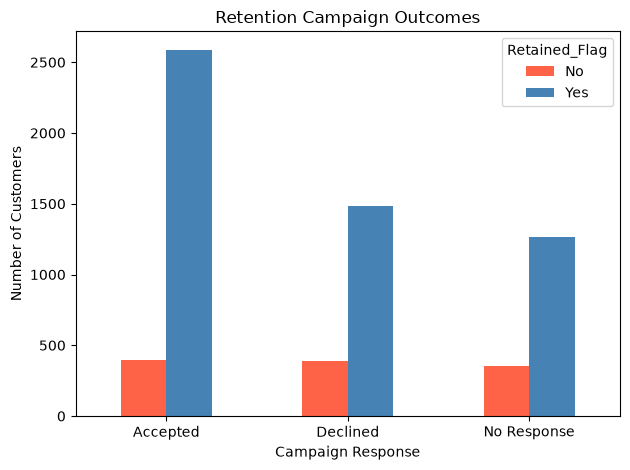

In [37]:
plt.figure(figsize=(8,5))

campaign_result.plot(
    kind="bar",
    color=["tomato", "steelblue"]
)

plt.title("Retention Campaign Outcomes")
plt.xlabel("Campaign Response")
plt.ylabel("Number of Customers")

plt.xticks(rotation=0)

plt.tight_layout()

# Save the chart
plt.savefig("retention_campaign_outcomes.png", dpi=300)

plt.show()

### Observation

This chart shows the outcomes of the customer retention campaigns, including customers who accepted, declined, or did not respond to the campaign offers. Customers who accepted the retention offers generally showed a higher retention rate, while declined or no-response cases were more likely to churn. These insights indicate that effective and targeted retention campaigns can improve customer loyalty and reduce churn.